<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB31 · PyTorch: redes neuronales con retropropagación automática

**Parte 4 · Aprendizaje por refuerzo de verdad — Lección 4**

> En el **NB19** entrenaste una red neuronal escribiendo **a mano** su retropropagación: la regla de la cadena eslabón a eslabón, neurona a
> neurona, con un bucle para cada una. Funcionó, y entendiste qué pasa por dentro. Pero imagina hacer eso para una red de 159.505 ruedecillas
> (la del humanoide, NB19) o, peor aún, cada vez que cambias la forma de la red. Imposible.

Hoy conocerás **PyTorch**, la biblioteca que usa casi toda la investigación en inteligencia artificial y robótica (la creó el equipo de
investigación de Meta, antes Facebook, y hoy es de código abierto). Hace tres cosas por ti:

1. **Calcula sola todas las pendientes** (la retropropagación), para cualquier red, por complicada que sea. Se llama **autograd**.
2. Trae **capas** ya hechas (lineales, ReLU, y muchas más) y **optimizadores** (formas listas de bajar por la pendiente).
3. Puede hacer todos los cálculos en una **tarjeta gráfica**, cientos de veces más rápido (lo usaremos en Colab).

Y no vas a encontrar magia: todo lo que hace ya lo sabes hacer a mano. La diferencia es que PyTorch lo hace **por ti**, sin errores, y rapidísimo.


## 1 · Tensores: los arrays de PyTorch

PyTorch ya está instalado en el entorno virtual del proyecto (NB26). Se importa con su nombre, `torch` (el nombre viene de un programa anterior, Torch, escrito en otro lenguaje):

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print("Versión de PyTorch:", torch.__version__)
_ = torch.manual_seed(0)          # la semilla de PyTorch (NB11): mismos números al azar cada vez

Versión de PyTorch: 2.14.1+cpu


La pieza básica de PyTorch es el **tensor**: un array de números, como los de NumPy (NB15). Se crean igual, y casi todo funciona igual:

In [2]:
t = torch.tensor([3.0, 4.0])
print(t)
print("forma:", t.shape, "| tipo:", t.dtype)
print("operaciones:", t + 1, t * t, t @ t)
print("longitud (NB12):", torch.sqrt((t ** 2).sum()))

tensor([3., 4.])
forma: torch.Size([2]) | tipo: torch.float32
operaciones: tensor([4., 5.]) tensor([ 9., 16.]) tensor(25.)
longitud (NB12): tensor(5.)


Fíjate en el tipo: **`float32`** por defecto (NB27: el de las tarjetas gráficas). Y se muestran con la palabra `tensor(...)` delante.

¿Por qué "tensor" y no "array"? En matemáticas, **tensor** es el nombre general de "una tabla de números de cualquier número de dimensiones": un número suelto es un tensor de 0 dimensiones, un
vector de 1, una matriz de 2, y una pila de matrices, de 3... Es lo mismo que un array de NumPy, con un nombre más elegante.

Pasar de NumPy a PyTorch y al revés es inmediato, y lo harás constantemente (los entornos de Gymnasium dan arrays de NumPy, NB15; las redes de PyTorch quieren tensores):


In [3]:
observacion = np.array([2.0, -1.5])
como_tensor = torch.tensor(observacion, dtype=torch.float32)
de_vuelta = como_tensor.numpy()
print(type(como_tensor), type(de_vuelta))

<class 'torch.Tensor'> <class 'numpy.ndarray'>


## 2 · Autograd: la pendiente, gratis

Ahora, el superpoder. Si al crear un tensor le dices **`requires_grad=True`** ("necesita gradiente"), PyTorch **apunta** todas las operaciones que hagas con él. Y luego, con una sola orden,
**`.backward()`** ("hacia atrás"), recorre esas operaciones **al revés**, aplicando la regla de la cadena (NB18), y deja la pendiente en el atributo **`.grad`**.

Probémoslo con lo más sencillo del mundo: la pendiente de f(x) = x² en x = 3, que en el NB16 descubrimos que es **6** (la de x² es 2x):


In [4]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()
print("pendiente de x² en x = 3:", x.grad)

pendiente de x² en x = 3: tensor(6.)


**6**, exacto. Sin tablas, sin h, sin ruido de decimales (NB16): PyTorch conoce la regla de cada operación (la pendiente de x² es 2x, la de una suma, la de un producto...) y las
**encadena**. Es la derivada **exacta**, no una aproximación.

Probemos con algo más gordo: la **pérdida** de la neurona imitadora del NB18. Allí, para calcular su pendiente respecto a w1, tuvimos que deducir con engranajes la fórmula 2 × media(error ×
entrada). Recreamos los mismos 300 ejemplos del maestro y comparamos:


In [5]:
import random

def maestro(inclinacion, velocidad):
    return -30 * inclinacion - 8 * velocidad

inclinaciones, velocidades, empujes = [], [], []
for semilla in range(3):                                   # los mismos ejemplos del NB18
    random.seed(semilla)
    inclinacion, velocidad = 2.0, 0.0
    for n in range(100):
        empuje = maestro(inclinacion, velocidad)
        inclinaciones.append(inclinacion); velocidades.append(velocidad); empujes.append(empuje)
        empuje = max(-40, min(40, empuje))
        velocidad += (10 * inclinacion + empuje + random.uniform(-30, 30)) * 0.02
        inclinacion += velocidad * 0.02

I = torch.tensor(inclinaciones, dtype=torch.float64)
V = torch.tensor(velocidades, dtype=torch.float64)
E = torch.tensor(empujes, dtype=torch.float64)

w1 = torch.tensor(-10.0, dtype=torch.float64, requires_grad=True)
w2 = torch.tensor(-2.0, dtype=torch.float64, requires_grad=True)
perdida = ((w1 * I + w2 * V - E) ** 2).mean()                # el error cuadrático medio (NB18)
perdida.backward()

print(f"pendiente respecto a w1 (PyTorch): {w1.grad.item():.4f}")
print(f"pendiente respecto a w2 (PyTorch): {w2.grad.item():.4f}")

pendiente respecto a w1 (PyTorch): 14.7596
pendiente respecto a w2 (PyTorch): -5.5572


(Usamos `float64` para comparar con todos los decimales; y `.item()` saca el número de un tensor de un solo elemento como un número normal de Python.)

**14,7596**: exactamente el número que calculamos en el NB18 con la regla de la cadena a mano (y con el gradiente numérico). Y de propina, la pendiente respecto a **w2**, sin escribir ni una
fórmula más. Con 3 ruedecillas o con 3 millones, el código es el mismo: `.backward()`.


### Cómo lo hace: el grafo de cálculo

Mientras calculas, PyTorch va construyendo un **grafo de cálculo**: un esquema de qué operación salió de qué, como los engranajes del NB18:

```
   w1 ──┐
        ├──► w1·I ──┐
   I ───┘           ├──► suma ──► − E ──► ( )² ──► media ──► pérdida
   w2 ──┐           │
        ├──► w2·V ──┘
   V ───┘
```

Al llamar a `.backward()`, recorre el esquema **de la pérdida hacia atrás**, multiplicando las pendientes de cada eslabón (la regla de la cadena), hasta llegar a cada tensor con
`requires_grad=True`. Es, literalmente, lo que hiciste a mano en el NB19, hecho por una máquina que no se equivoca.


### Una trampa: las pendientes se acumulan

Un detalle importantísimo que confunde a todo el mundo la primera vez. Si llamas a `.backward()` **dos veces**, PyTorch **suma** la nueva pendiente a la que ya había en `.grad`:

In [6]:
x = torch.tensor(3.0, requires_grad=True)
(x ** 2).backward()
print("tras el primer backward: ", x.grad)
(x ** 2).backward()
print("tras el segundo backward:", x.grad)

tras el primer backward:  tensor(6.)
tras el segundo backward: tensor(12.)


¡**12**, no 6! La segunda pendiente se ha **sumado** a la primera. (Lo hace a propósito, porque a veces es útil acumular pendientes de varias partes.) Pero en un bucle de entrenamiento,
donde calculas la pendiente una y otra vez, hay que **ponerla a cero** antes de cada nuevo cálculo. Si se te olvida, las pendientes se van acumulando de un paso a otro y el entrenamiento se vuelve
loco. Es uno de los fallos más típicos con PyTorch (añádelo a la lista de bichos del NB22).

### Cuando no quieres pendientes: `torch.no_grad()`

Al **usar** una red ya entrenada (por ejemplo, para que el robot decida en un episodio), no hace falta apuntar operaciones para calcular pendientes: solo gasta memoria y tiempo. Para eso existe
`torch.no_grad()`, un gestor de contexto (con `with`, NB26):


In [7]:
x = torch.tensor(3.0, requires_grad=True)
with torch.no_grad():
    y = x ** 2
print("¿y apunta operaciones?", y.requires_grad)

¿y apunta operaciones? False


## 3 · Capas ya hechas

PyTorch trae las piezas de una red neuronal en el módulo `torch.nn` (*nn* = *neural networks*, "redes neuronales"). La más importante, **`nn.Linear`**: una **capa lineal** completa (la del NB14:
matriz de pesos + sesgos), con sus pesos ya creados al azar y con `requires_grad=True`:


In [8]:
from torch import nn

capa = nn.Linear(2, 3)            # 2 entradas, 3 salidas
print(capa)
print("pesos:", capa.weight.shape, "| sesgos:", capa.bias.shape)
print("salida para una observación:", capa(torch.tensor([2.0, -1.5])))

Linear(in_features=2, out_features=3, bias=True)
pesos: torch.Size([3, 2]) | sesgos: torch.Size([3])
salida para una observación: tensor([-0.5936,  0.1773, -0.8919], grad_fn=<ViewBackward0>)


Una capa de 2 entradas y 3 salidas tiene una matriz de pesos de forma (3, 2) (NB14: filas = salidas) y 3 sesgos. Y se **llama** como una función con una entrada (¡el `__call__` del NB24!).

Para encadenar capas, **`nn.Sequential`** las pone una detrás de otra, y **`nn.ReLU()`** es el codo del NB19. La red del NB19 (1 entrada, 8 neuronas ocultas con ReLU, 1 salida) queda en **tres
líneas**:


In [9]:
red = nn.Sequential(
    nn.Linear(1, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)
print(red)
print("Número de ruedecillas:", sum(p.numel() for p in red.parameters()))

Sequential(
  (0): Linear(in_features=1, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
Número de ruedecillas: 25


**25 ruedecillas**: 8 pesos de entrada + 8 sesgos ocultos + 8 pesos de salida + 1 sesgo de salida, exactamente como en el NB19. (`red.parameters()` recorre todos los tensores de ruedecillas
de la red, y `numel()` cuenta los números de cada uno.)

`nn.Sequential` es cómodo para redes en fila. Para redes más complicadas se escribe una **clase** que hereda de `nn.Module`, como te adelanté en el NB25. La misma red, como clase:


In [10]:
class RedPequena(nn.Module):
    def __init__(self, ocultas=8):
        super().__init__()                      # ¡lo primero! (NB25)
        self.capa1 = nn.Linear(1, ocultas)
        self.capa2 = nn.Linear(ocultas, 1)

    def forward(self, x):                       # el método obligatorio: cómo se calcula la salida
        return self.capa2(torch.relu(self.capa1(x)))

print(RedPequena())

RedPequena(
  (capa1): Linear(in_features=1, out_features=8, bias=True)
  (capa2): Linear(in_features=8, out_features=1, bias=True)
)


Las dos formas son equivalentes. La de la clase da libertad total en `forward` (por ejemplo, tener dos salidas, como un actor y un crítico que comparten parte de la red).


## 4 · Optimizadores: bajar por la pendiente sin escribirlo

En el NB18-19, después de calcular las pendientes, actualizábamos **cada** ruedecilla a mano: `w = w - tasa * pendiente`. PyTorch trae esto hecho en **`torch.optim`**: un **optimizador**
recibe las ruedecillas de la red y, con `.step()`, las mueve un paso cuesta abajo. El más sencillo, **`SGD`**, hace exactamente nuestro descenso por gradiente (NB17-18). (SGD significa *stochastic
gradient descent*, "descenso por gradiente estocástico": "estocástico" porque normalmente se usa con lotes al azar de los datos, NB23.)

Con todas las piezas, **el bucle de entrenamiento de PyTorch** tiene siempre la misma forma, cinco líneas que verás en cualquier proyecto del mundo:

```python
for paso in range(pasos):
    prediccion = red(entradas)                  # 1. hacia delante
    perdida = funcion_de_perdida(prediccion, objetivos)   # 2. cuánto se equivoca
    optimizador.zero_grad()                     # 3. pendientes a cero (¡la trampa de antes!)
    perdida.backward()                          # 4. hacia atrás: todas las pendientes
    optimizador.step()                          # 5. un paso cuesta abajo
```

Vamos a rehacer el NB19: imitar al maestro que **satura** (empuja −30 por grado, con un límite de ±40). Los datos, como entonces (pero como tensores en columna, de forma (61, 1), porque las capas
esperan una fila por ejemplo):


In [11]:
inclinaciones = torch.linspace(-3, 3, 61).reshape(-1, 1)          # (61, 1)
empujes_maestro = torch.clamp(-30 * inclinaciones, -40, 40)       # clamp = el clip de NumPy
print(inclinaciones.shape, empujes_maestro.shape)

torch.Size([61, 1]) torch.Size([61, 1])


Y el entrenamiento, con `SGD` y la tasa del NB19 (0,003), 5.000 pasos. La pérdida es el error cuadrático medio, que PyTorch trae hecho como `nn.MSELoss()` (*mean squared error*):

In [12]:
def entrenar(red, optimizador, pasos=5000):
    funcion_de_perdida = nn.MSELoss()
    historial = []
    for paso in range(pasos):
        prediccion = red(inclinaciones)
        perdida = funcion_de_perdida(prediccion, empujes_maestro)
        optimizador.zero_grad()
        perdida.backward()
        optimizador.step()
        historial.append(perdida.item())
    return historial

torch.manual_seed(0)
red_sgd = RedPequena()
historial_sgd = entrenar(red_sgd, torch.optim.SGD(red_sgd.parameters(), lr=0.003))
print(f"SGD: pérdida inicial {historial_sgd[0]:.1f} -> final {historial_sgd[-1]:.4f}")

SGD: pérdida inicial 1168.9 -> final 0.7122


Lo que en el NB19 fue una celda enorme, con la regla de la cadena para cada neurona, aquí son **cinco líneas** dentro del bucle. Y PyTorch ha calculado las pendientes de las 25 ruedecillas sin que
escribamos ninguna fórmula. (La pérdida final depende de dónde empezaron los pesos al azar: con algunas semillas llega casi a 0, y con otras se atasca en un óptimo local, como vimos en el NB19.)


### Un optimizador más listo: Adam

`SGD` usa la misma tasa para todas las ruedecillas y no recuerda nada de los pasos anteriores. Hay optimizadores más listos. El más usado del mundo se llama **Adam** (de *adaptive moment estimation*).
Sin entrar en sus fórmulas, hace dos cosas muy sensatas:

1. **Inercia** (NB02): si varias pendientes seguidas apuntan en la misma dirección, va cogiendo velocidad en esa dirección, como una bola que rueda cuesta abajo. Si cambian de dirección cada vez
   (oscilaciones, NB17), las inercias se cancelan y se calma.
2. **Una tasa a la medida de cada ruedecilla**: las ruedecillas cuyas pendientes son siempre enormes dan pasos más prudentes, y las de pendientes minúsculas, pasos más grandes. Así no hace falta que
   todas tengan la misma escala.

Es la primera opción en la inmensa mayoría de proyectos (y la que usan los algoritmos de RL para robots). Cambiarlo es cambiar **una palabra**. Probémoslo en nuestro problema, con la misma
semilla:


Adam: pérdida inicial 1168.9 -> final 29.9443


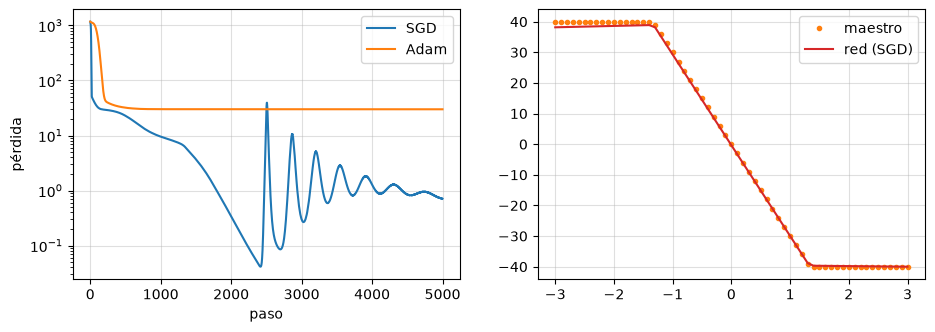

In [13]:
torch.manual_seed(0)
red_adam = RedPequena()
historial_adam = entrenar(red_adam, torch.optim.Adam(red_adam.parameters(), lr=0.01))
print(f"Adam: pérdida inicial {historial_adam[0]:.1f} -> final {historial_adam[-1]:.4f}")

plt.figure(figsize=(11, 3.5))
plt.subplot(1, 2, 1)
plt.plot(historial_sgd, label="SGD")
plt.plot(historial_adam, label="Adam")
plt.yscale("log")
plt.xlabel("paso")
plt.ylabel("pérdida")
plt.legend()
plt.grid(True, alpha=0.4)

plt.subplot(1, 2, 2)
with torch.no_grad():
    plt.plot(inclinaciones, empujes_maestro, "o", markersize=3, color="tab:orange", label="maestro")
    plt.plot(inclinaciones, red_sgd(inclinaciones), color="tab:red", label="red (SGD)")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

¡Sorpresa! Con esta semilla, **SGD** baja la pérdida casi a 0 (a la derecha, su red calca al maestro, con sus dos esquinas), pero **Adam se atasca** en una pérdida de unos 30 y no sale de ahí.
Mirando la curva, Adam baja **muy deprisa** al principio... y se queda clavado. Lo que ha pasado es un **óptimo local** (NB17, NB19): con sus pasos rápidos, Adam ha colocado los codos de la red en
una forma que imita bien una parte del maestro pero no la otra, y desde ahí ya no sabe salir.

Lo he comprobado con más semillas y otras tasas: en este problema concreto (una red diminuta, 8 neuronas, y un maestro con esquinas), Adam se atasca casi siempre en ese mismo sitio, y SGD llega
al final en la mayoría de los casos. Con una red más ancha (32 neuronas, ejercicio E7), SGD aprende en todas las semillas que probé, y Adam solo en algunas.

¿Entonces Adam es peor? **No en general**: en redes grandes y problemas reales (como los robots), suele ser más rápido y más cómodo, y por eso es el que se usa casi siempre. La lección es otra, y muy
importante para tu trabajo: **ningún optimizador es mágico**. Cada uno tiene problemas en los que brilla y otros en los que falla, y la única forma de saberlo es **probar y medir** (con varias semillas,
NB29). Cuando un entrenamiento se atasca, cambiar de optimizador, de tasa o el tamaño de la red son las primeras cosas que se prueban.


## 5 · Una política estocástica con PyTorch

Y ahora, la conexión con el aprendizaje por refuerzo. En el NB29, la pieza central de REINFORCE era la **pendiente de la log-probabilidad** de una acción respecto a las ruedecillas, que dedujimos a
mano: **(a − μ)/σ² × observación**. Con PyTorch, ni eso hace falta.

PyTorch trae las distribuciones de probabilidad del NB28 en `torch.distributions`. **`Normal(media, sigma)`** es la campana de Gauss, y su método **`log_prob(accion)`** da la log-probabilidad de una
acción. Construyamos la política del NB29 (una neurona lineal con dos pesos, más una campana de σ = 5) y pidámosle a PyTorch la pendiente de la log-probabilidad:


In [14]:
from torch.distributions import Normal

pesos = torch.tensor([-5.0, -3.0], requires_grad=True)          # las ruedecillas de la política
observacion = torch.tensor([2.0, 1.0])
sigma = 5.0

media = observacion @ pesos                                      # μ = pesos · observación
campana = Normal(media, sigma)
accion = torch.tensor(-10.0)                                     # una acción que (supongamos) se sorteó
campana.log_prob(accion).backward()                              # ¡la pendiente, automática!

print("media μ:", media.item())
print("pendiente de PyTorch:      ", pesos.grad)
print("fórmula del NB29 (a−μ)/σ²·obs:", (accion - media.detach()) / sigma ** 2 * observacion)

media μ: -13.0
pendiente de PyTorch:       tensor([0.2400, 0.1200])
fórmula del NB29 (a−μ)/σ²·obs: tensor([0.2400, 0.1200])


(`.detach()` "despega" un tensor del grafo de cálculo: lo usamos para calcular la fórmula a mano sin que PyTorch la apunte.)

**Las dos coinciden.** PyTorch ha calculado sola la pieza central de REINFORCE. Y aquí está lo importante: si la media la calculara una **red neuronal** de miles de ruedecillas en vez de una neurona,
**el código sería el mismo**: `Normal(red(observacion), sigma).log_prob(accion).backward()`, y tendríamos la pendiente de todas las ruedecillas de la red.

Además, la propia σ (la exploración) puede ser una **ruedecilla más**, con `requires_grad=True`, y entonces el robot **aprende cuánto explorar** (lo anunciamos en el NB28). Todo eso lo haremos en el
próximo notebook.


## 6 · Guardar y cargar una red

Una red entrenada hay que **guardarla** (NB26). En PyTorch, las ruedecillas de una red se obtienen con **`state_dict()`** ("diccionario del estado"), que es... un **diccionario** (NB21) de nombre de capa →
tensor de pesos. Se guarda con `torch.save` y se carga con `torch.load`:


In [15]:
from pathlib import Path

carpeta = Path("practica_nb31")
carpeta.mkdir(exist_ok=True)

print("Claves del state_dict:", list(red_sgd.state_dict().keys()))
torch.save(red_sgd.state_dict(), carpeta / "red_maestro.pt")

red_cargada = RedPequena()                                                      # una red nueva, con pesos al azar...
red_cargada.load_state_dict(torch.load(carpeta / "red_maestro.pt", weights_only=True))   # ...que recibe los guardados

with torch.no_grad():
    print("¿Responde igual que la original?", torch.allclose(red_cargada(inclinaciones), red_sgd(inclinaciones)))

Claves del state_dict: ['capa1.weight', 'capa1.bias', 'capa2.weight', 'capa2.bias']
¿Responde igual que la original? True


La red cargada responde **exactamente** igual que la entrenada. (`torch.allclose` es el `np.testing.assert_allclose` del NB27: "¿iguales, salvo diminutas diferencias de decimales?").

Fíjate en **`weights_only=True`** al cargar. ¿Recuerdas el peligro del **pickle** (NB26)? `torch.save` usa pickle por dentro, así que un fichero `.pt` malicioso podría ejecutar código al cargarlo. Con
`weights_only=True`, PyTorch solo acepta **números** (los pesos), y rechaza cualquier otra cosa. **Úsalo siempre** al cargar redes, sobre todo si las has descargado de internet.


## 7 · Tarjetas gráficas

Todo lo de hoy se ha ejecutado en el procesador de la Raspberry Pi (la **CPU**), y para redes pequeñas va de sobra. Pero para entrenar un humanoide, con redes más grandes y millones de pasos, hace falta una
**GPU** (la tarjeta gráfica), que hace miles de multiplicaciones **a la vez**. En PyTorch, mover una red y sus datos a la GPU es una línea:

```python
dispositivo = "cuda" if torch.cuda.is_available() else "cpu"     # "cuda" = las GPU de NVIDIA
red = red.to(dispositivo)
datos = datos.to(dispositivo)
```

El resto del código **no cambia**. Por eso los cuadernos de entrenamiento pesado de este curso estarán preparados para **Google Colab**, que presta GPU gratis: el mismo código, mucho más rápido. En la Pi:


In [16]:
print("¿Hay GPU disponible aquí?", torch.cuda.is_available())

¿Hay GPU disponible aquí? False


## 8 · Resumen de la lección

1. **PyTorch** (`import torch`): la biblioteca estándar de redes neuronales. Su pieza básica es el **tensor** (como un array de NumPy, `float32` por defecto; `torch.tensor`, `.numpy()`).
2. **Autograd**: con `requires_grad=True`, PyTorch apunta las operaciones (el **grafo de cálculo**) y `.backward()` calcula las pendientes **exactas** con la regla de la cadena, en `.grad`: 6 para x² en 3
   (NB16), 14,7596 para la neurona del NB18. **Las pendientes se acumulan**: hay que ponerlas a cero (`zero_grad`). `torch.no_grad()` para usar sin entrenar.
3. Capas en `torch.nn`: `nn.Linear`, `nn.ReLU`, `nn.Sequential`, o una clase que hereda de **`nn.Module`** con su `forward`. La red del NB19 en tres líneas (25 ruedecillas).
4. **Optimizadores** (`torch.optim`): `SGD` (el descenso del NB17) y **Adam** (con inercia y tasas a medida; el más usado, pero **no mágico**: aquí se atascó en un óptimo local y SGD no). El bucle de entrenamiento: predecir → pérdida (`nn.MSELoss`) → `zero_grad` → `backward` →
   `step`.
5. `torch.distributions.Normal(...).log_prob(a)`: la pendiente de la log-probabilidad (la pieza de REINFORCE, NB29) sale **automática**, para cualquier red. Guardar con **`state_dict`** y cargar con
   **`weights_only=True`**. Para entrenar en **GPU**, `.to("cuda")`.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **PyTorch / `torch`** | La biblioteca más usada para redes neuronales. |
| **Tensor** | Una tabla de números de cualquier dimensión (como un array de NumPy). |
| **Autograd** | El cálculo automático de pendientes de PyTorch. |
| **`requires_grad` / `.backward()` / `.grad`** | Pedir pendientes / calcularlas / leerlas. |
| **Grafo de cálculo** | El esquema de operaciones que PyTorch apunta para recorrerlo hacia atrás. |
| **`zero_grad`** | Poner las pendientes a cero antes de calcular las nuevas. |
| **`torch.no_grad()`** | Usar la red sin apuntar operaciones (sin entrenar). |
| **`nn.Linear` / `nn.ReLU` / `nn.Sequential`** | Capa lineal / activación ReLU / capas en fila. |
| **`nn.Module` / `forward`** | La clase madre de toda red / el método que calcula su salida. |
| **Optimizador (`SGD`, `Adam`)** | Lo que mueve las ruedecillas cuesta abajo; Adam, con inercia y tasas a medida. |
| **`nn.MSELoss`** | El error cuadrático medio, ya hecho. |
| **`torch.distributions.Normal`** | La campana de Gauss, con su `log_prob`. |
| **`state_dict`** | El diccionario con todas las ruedecillas de una red. |
| **CPU / GPU / `cuda`** | El procesador / la tarjeta gráfica / el nombre de las GPU de NVIDIA en PyTorch. |


## 9 · Ejercicios

**E1.** Con autograd, calcula la pendiente de f(x) = x³ en x = 2. ¿Coincide con la regla del NB16 (3x²)?

**E2.** ¿Qué pasaría en el bucle de entrenamiento si quitaras la línea `optimizador.zero_grad()`? Pruébalo con la red pequeña y SGD durante 200 pasos y mira la pérdida.

**E3.** ¿Cuántas ruedecillas tiene `nn.Sequential(nn.Linear(348, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 17))`? Compruébalo con `numel` y compáralo con el NB19.

**E4.** Rehaz el **NB18** con PyTorch: una sola capa `nn.Linear(2, 1)` que aprenda a imitar al maestro −30 × inclinación − 8 × velocidad a partir de los 300 ejemplos del apartado 2 (los tensores `I`, `V`,
`E`). ¿Recupera los números? (Pista: junta `I` y `V` en una tabla con `torch.stack([I, V], dim=1).float()`, y usa Adam.)

**E5.** Con la política del apartado 5, haz σ también aprendible (`sigma = torch.tensor(5.0, requires_grad=True)`) y calcula la pendiente de la log-probabilidad respecto a σ para la acción −10. ¿Qué signo
tiene? ¿Qué significa? (Pista: la acción estaba lejos de la media.)

**E7.** Repite la comparación SGD contra Adam con una red **más ancha**: `RedPequena(ocultas=32)`, 3.000 pasos, y varias semillas (0 a 3). ¿Qué pasa ahora?

**E6.** **Reto.** Escribe la red del humanoide del NB19 (348 → 256 → 256 → 17) como una clase `RedPolitica(nn.Module)` y pásale una observación de mentira (`torch.zeros(348)`). ¿Qué forma tiene la salida?


<details>
<summary>▶ Solución E1</summary>

```python
x = torch.tensor(2.0, requires_grad=True)
(x ** 3).backward()
print(x.grad)          # tensor(12.)
```

**12** = 3 × 2². Exacto, como dice la regla del NB16.
</details>

<details>
<summary>▶ Solución E2</summary>

Sin `zero_grad`, cada `backward` **suma** su pendiente a las de todos los pasos anteriores. La "pendiente" que usa el optimizador va creciendo sin parar (es la suma de todas las pendientes pasadas), los pasos se
hacen cada vez más grandes y el entrenamiento se descontrola: la pérdida empieza bajando y luego oscila o se dispara. Es la trampa del apartado 2, y uno de los fallos más típicos con PyTorch.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
red_grande = nn.Sequential(nn.Linear(348, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 17))
print(sum(p.numel() for p in red_grande.parameters()))     # 159505
```

**159.505**, exactamente la cuenta que hicimos a mano en el NB19.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
X = torch.stack([I, V], dim=1).float()        # (300, 2)
y = E.float().reshape(-1, 1)                  # (300, 1)
neurona = nn.Linear(2, 1)
optimizador = torch.optim.Adam(neurona.parameters(), lr=0.5)
for paso in range(2000):
    perdida = nn.MSELoss()(neurona(X), y)
    optimizador.zero_grad()
    perdida.backward()
    optimizador.step()
print(neurona.weight.data, neurona.bias.data)
```

Los pesos se acercan a **(−30, −8)** y el sesgo a 0, como en el NB18, sin escribir la regla de la cadena. (`.data` muestra los números sin la información del grafo.) Si no llega del todo, prueba más pasos o
ajusta la tasa: Adam también tiene su tasa a ajustar.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
pesos = torch.tensor([-5.0, -3.0], requires_grad=True)
sigma = torch.tensor(5.0, requires_grad=True)
media = torch.tensor([2.0, 1.0]) @ pesos
Normal(media, sigma).log_prob(torch.tensor(-10.0)).backward()
print(sigma.grad)
```

La media es −13, y la acción, −10: está a 3 de la media, es decir, a 0,6 σ. La pendiente respecto a σ sale **negativa**: para que esa acción, **que está bastante cerca del centro**, sea más probable, conviene
**estrechar** la campana (bajar σ). Si la acción hubiera estado **muy lejos** de la media (más de una σ), la pendiente saldría positiva: convendría ensanchar la campana para alcanzarla. Así, si las acciones
alejadas salen bien, el robot aprende a **explorar más**; si salen mal, a explorar menos.
</details>

<details>
<summary>▶ Solución E7</summary>

```python
for nombre, Optimizador, tasa in [("SGD", torch.optim.SGD, 0.003), ("Adam", torch.optim.Adam, 0.03)]:
    finales = []
    for semilla in range(4):
        torch.manual_seed(semilla)
        red = RedPequena(ocultas=32)
        finales.append(round(entrenar(red, Optimizador(red.parameters(), lr=tasa), pasos=3000)[-1], 3))
    print(nombre, finales)
```

Con 32 neuronas, SGD aprende en **las cuatro** semillas (pérdida final de centésimas), llegando por debajo de 1 hacia el paso 900. Adam (tasa 0,03) aprende en algunas semillas, a veces **más deprisa**
que SGD (hacia el paso 500-600), pero en otras se atasca. Más neuronas = más codos de sobra = menos óptimos locales (NB19), y aun así, en este problema, SGD es más fiable. Probar varias semillas es lo
único que te lo dice.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
class RedPolitica(nn.Module):
    def __init__(self):
        super().__init__()
        self.capa1 = nn.Linear(348, 256)
        self.capa2 = nn.Linear(256, 256)
        self.salida = nn.Linear(256, 17)

    def forward(self, observacion):
        x = torch.relu(self.capa1(observacion))
        x = torch.relu(self.capa2(x))
        return self.salida(x)

print(RedPolitica()(torch.zeros(348)).shape)     # torch.Size([17])
```

Forma **(17,)**: una acción por motor. Ya sabes escribir, con PyTorch, la red que mueve a un humanoide.
</details>


## 10 · 🛠 Práctica en MuJoCo: una red de PyTorch controla el palo de escoba

En la práctica del NB29 entrenaste el palo de escoba de MuJoCo con una neurona de NumPy, y la pendiente la escribías **a mano**:
`(a − μ)/σ² × observación`. Hoy has visto que PyTorch la calcula sola (apartado 5). Así que hoy:

1. Comprobarás que la flecha del NB29, en MuJoCo, sale **idéntica** con autograd.
2. Entrenarás la misma neurona con un optimizador de PyTorch (SGD).
3. Cambiarás la neurona por una **red neuronal** de verdad (`nn.Module`, ReLU, Adam), y descubrirás un detalle que separa una red que
   aprende de una que no: el **tamaño de los números que le entran**.
4. Filmarás la red controlando el palo y la **guardarás** con `state_dict`.

Es el paso que da toda la robótica moderna: **un simulador de física (MuJoCo) + una red neuronal (PyTorch)**.


### Paso 1 · Preparar el taller

Tres cosas: el `jugar_mujoco` que guardaste en el NB29; la función `retornos_desde_cada_paso` del NB29 (la copiamos, son seis líneas); y una
orden nueva, `torch.set_num_threads(1)`, que le dice a PyTorch que use **un solo núcleo** del procesador. Con redes tan pequeñas, repartir
cada cuentecita entre los cuatro núcleos de la Pi cuesta más de lo que ahorra (y así dejas los otros libres).


In [17]:
from practica_mujoco.nb29_palo_mujoco import jugar_mujoco
import taller

torch.set_num_threads(1)
SIGMA_MJ = 0.3                     # la exploración del NB29, en unidades del motor (−1 a 1)

def retornos_desde_cada_paso(recompensas, gamma=0.99):
    G = np.zeros_like(recompensas)
    acumulado = np.zeros(recompensas.shape[1], dtype=np.float32)
    for t in reversed(range(recompensas.shape[0])):
        acumulado = recompensas[t] + gamma * acumulado
        G[t] = acumulado
    return G

### Paso 2 · Una red de PyTorch como política de MuJoCo

`jugar_mujoco` quiere una **función** que reciba las observaciones de NumPy y devuelva las medias en NumPy. Una red de PyTorch quiere
tensores. Hacemos de traductor: NumPy → tensor (`torch.from_numpy`, en `float32`) → red → `.numpy()`. Y todo dentro de `torch.no_grad()`
(apartado 2): para **jugar** no hacen falta pendientes.

La primera "red" es la neurona del NB29: `nn.Linear(2, 1, bias=False)` (dos pesos, sin sesgo), con los pesos (1; 0,2) puestos a mano.
`squeeze(-1)` quita la última dimensión, que mide 1: la red da una tabla (n, 1) y queremos n medias.


In [18]:
def como_politica(red):
    def politica(observaciones):
        with torch.no_grad():
            return red(torch.from_numpy(observaciones.astype(np.float32))).squeeze(-1).numpy()
    return politica

neurona = nn.Linear(2, 1, bias=False)
with torch.no_grad():
    neurona.weight[:] = torch.tensor([[1.0, 0.2]])

obs, acc, med, rec, vivo = jugar_mujoco(como_politica(neurona), SIGMA_MJ, 50, np.random.default_rng(0))
print("Retorno medio con la neurona (1; 0,2):", round(float((rec * vivo).sum(axis=0).mean()), 1))

Retorno medio con la neurona (1; 0,2): 153.3


### Paso 3 · La flecha del NB29, con autograd

Con un lote ya jugado, calculamos la dirección de mejora de **dos** formas:

- **A mano**, con la fórmula del NB29: media sobre episodios de la suma sobre pasos de ventaja × (a − μ)/σ² × observación.
- **Con autograd**: el "objetivo" = media sobre episodios de la suma sobre pasos de ventaja × log-probabilidad de la acción (`Normal(...).log_prob`, apartado 5), y `.backward()`.

La ventaja, la del NB29: el retorno desde cada paso menos su media en ese paso, y a cero en los pasos con el palo ya en el suelo.


In [19]:
G = retornos_desde_cada_paso(rec)
ventajas = (G - G.mean(axis=1, keepdims=True)) * vivo                     # la línea base del NB29

# 1) a mano (NB29)
a_mano = (ventajas[..., None] * ((acc - med) / SIGMA_MJ ** 2)[..., None] * obs).sum(axis=0).mean(axis=0)

# 2) con autograd
medias = neurona(torch.from_numpy(obs)).squeeze(-1)                       # (300, 50), ahora SÍ con pendientes
log_prob = Normal(medias, SIGMA_MJ).log_prob(torch.from_numpy(acc))
objetivo = (log_prob * torch.from_numpy(ventajas)).sum(dim=0).mean()
neurona.zero_grad()
objetivo.backward()

print("a mano (NB29):", a_mano)
print("autograd:     ", neurona.weight.grad)

a mano (NB29): [61.21471  85.661766]
autograd:      tensor([[61.2148, 85.6617]])


**Iguales** (salvo el último decimal, por los `float32`). Fíjate en que aquí la red recibe de golpe las 300 × 50 observaciones del lote: una
tabla de forma (300, 50, 2), y `nn.Linear` la trata sin pestañear (trabaja con la **última** dimensión, NB15). La fórmula a mano, para la
que necesitamos dos lecciones (NB28b y NB29), es ahora una llamada a `.backward()`.


### Paso 4 · Entrenar con un optimizador de PyTorch

Ahora el bucle de entrenamiento con las cinco líneas del apartado 4. Un detalle: el optimizador **baja** la pérdida, y nosotros queremos
**subir** el objetivo. Solución: la pérdida es **menos** el objetivo (bajar −x es subir x). En el NB32 lo verás con calma; hoy basta con eso.

Con `SGD` y la tasa del NB29 (0,003), dar un paso es exactamente `pesos = pesos + 0,003 × flecha`: **es REINFORCE del NB29**, escrito con
PyTorch. 50 iteraciones de 50 episodios, unos 15 segundos:


In [20]:
def entrenar_red(red, optimizador, iteraciones=50, semilla=0):
    generador = np.random.default_rng(semilla)
    historial = []
    for iteracion in range(iteraciones):
        obs, acc, med, rec, vivo = jugar_mujoco(como_politica(red), SIGMA_MJ, 50, generador)   # jugar (sin pendientes)
        historial.append(float((rec * vivo).sum(axis=0).mean()))
        G = retornos_desde_cada_paso(rec)
        ventajas = torch.from_numpy((G - G.mean(axis=1, keepdims=True)) * vivo)
        medias = red(torch.from_numpy(obs)).squeeze(-1)                                        # ahora sí, con pendientes
        objetivo = (Normal(medias, SIGMA_MJ).log_prob(torch.from_numpy(acc)) * ventajas).sum(dim=0).mean()
        perdida = -objetivo                         # bajar −objetivo = subir el objetivo
        optimizador.zero_grad()
        perdida.backward()
        optimizador.step()
    return historial

import time
inicio = time.time()
neurona = nn.Linear(2, 1, bias=False)
nn.init.zeros_(neurona.weight)                     # empieza sin saber nada, como en el NB29
historial_neurona = entrenar_red(neurona, torch.optim.SGD(neurona.parameters(), lr=0.003))
print(f"Tiempo: {time.time() - inicio:.0f} s | pesos aprendidos: {neurona.weight.data.numpy().round(2)}")
print("Retorno cada 5 iteraciones:", [round(x) for x in historial_neurona[::5]])

Tiempo: 12 s | pesos aprendidos: [[2.24 0.93]]
Retorno cada 5 iteraciones: [70, 204, 249, 248, 250, 222, 224, 293, 288, 297]


Aprende como en el NB29, desde ~70 puntos hasta cerca de 300, y con pesos **positivos** (meter el carro debajo del palo). Por el camino
da algún tropiezo (mira la lista): REINFORCE con SGD tiene sus días malos.

(`nn.init.zeros_` pone a cero los pesos de una capa; el guion bajo final es la costumbre de PyTorch para "modifica el tensor en el sitio".)


### Paso 5 · Una red de verdad... y el tamaño de sus números

Ahora cambiamos la neurona por una red como la del apartado 3: 2 entradas → 16 neuronas ReLU → 1 salida, como clase `nn.Module`, con el
optimizador **Adam** (tasa 0,01). Pero antes, un detalle que decide si aprenderá o no.

Mira las observaciones de MuJoCo: el ángulo va en **radianes**, y un palo inclinado 3° está a **0,05** rad. Para una red recién nacida, cuyas
ruedecillas empiezan con valores al azar de tamaño ~0,5, una entrada de 0,05 es casi **cero**: la señal más importante (cuánto se inclina el
palo) le llega susurrando. Las redes aprenden mucho mejor cuando sus entradas son de tamaño **1**, más o menos (como la normalización del
NB27). Así que, **dentro** de la red, dividimos el ángulo entre 0,1 (3° pasa a ser 0,5) y dejamos el giro, que ya anda por las unidades.


In [21]:
class PoliticaRed(nn.Module):
    def __init__(self, ocultas=16):
        super().__init__()
        self.capa1 = nn.Linear(2, ocultas)
        self.capa2 = nn.Linear(ocultas, 1)
        self.escala = torch.tensor([0.1, 1.0])           # ángulo / 0,1 ; giro / 1

    def forward(self, observaciones):
        return self.capa2(torch.relu(self.capa1(observaciones / self.escala)))

torch.manual_seed(0)
red = PoliticaRed()
print("Ruedecillas:", sum(p.numel() for p in red.parameters()))

inicio = time.time()
historial_red = entrenar_red(red, torch.optim.Adam(red.parameters(), lr=0.01))
print(f"Tiempo: {time.time() - inicio:.0f} s")
print("Retorno cada 5 iteraciones:", [round(x) for x in historial_red[::5]])

Ruedecillas: 65


Tiempo: 33 s
Retorno cada 5 iteraciones: [63, 99, 245, 297, 299, 299, 299, 299, 299, 300]


(La escala es un tensor normal, no una ruedecilla: no aparece en `parameters()` y el optimizador no la toca. Por eso salen 65 ruedecillas:
2 × 16 + 16 de la primera capa, 16 + 1 de la segunda.)

**La red aprende, y deprisa**: de unos 60 puntos a casi **300** en unas 15 iteraciones, y ahí se queda, rozando el máximo, sin los tropiezos de
la neurona con SGD. Dibujemos las dos curvas:


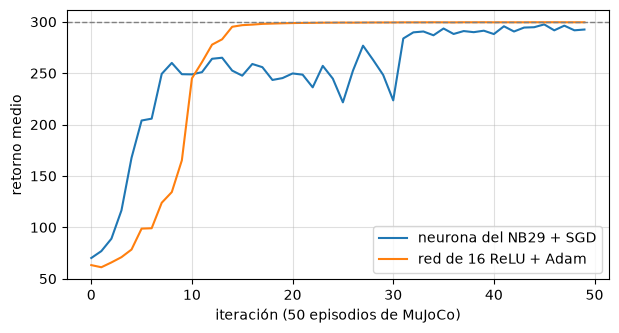

In [22]:
plt.figure(figsize=(7, 3.5))
plt.plot(historial_neurona, label="neurona del NB29 + SGD")
plt.plot(historial_red, label="red de 16 ReLU + Adam")
plt.axhline(300, color="gray", linestyle="--", linewidth=1)
plt.xlabel("iteración (50 episodios de MuJoCo)")
plt.ylabel("retorno medio")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

### Paso 6 · El examen y el vídeo

El examen del NB29: la red **sin explorar** (σ = 0) con 100 palos nuevos de 3 segundos. Y luego la filmamos con `taller.video`, que
necesita una función `control(modelo, datos)`: se la fabricamos con la red, leyendo la observación de `datos.qpos` y `datos.qvel`.


In [23]:
obs, acc, med, rec, vivo = jugar_mujoco(como_politica(red), 0.0, 100, np.random.default_rng(123))
print(f"Retorno medio {(rec * vivo).sum(axis=0).mean():.1f} | se caen antes de los 3 s: {(~vivo[-1]).sum()} de 100")

def control_con_red(red):
    def control(modelo, datos):
        observacion = torch.tensor([[datos.qpos[1], datos.qvel[1]]], dtype=torch.float32)
        with torch.no_grad():
            datos.ctrl[0] = float(red(observacion).clamp(-1, 1))
    return control

modelo_video, datos_video = taller.cargar("palo_escoba")
datos_video.qpos[1] = np.radians(4)
taller.video(modelo_video, datos_video, segundos=3, control=control_con_red(red), nombre="nb31_red_pytorch")
print(f"A los 3 s: palo a {np.degrees(datos_video.qpos[1]):.1f} grados | carro en x = {datos_video.qpos[0]:.2f} m")

Retorno medio 299.9 | se caen antes de los 3 s: 0 de 100


A los 3 s: palo a 0.0 grados | carro en x = 0.13 m


**Ninguno se cae**, y en el vídeo verás el carro meterse bajo el palo y enderezarlo. Una red de PyTorch está moviendo un motor dentro de
un simulador de física. (Fíjate también en el carro: igual que en el NB29, esta red **solo ve el palo**, así que el carro no tiene por qué
quedarse en el centro.)


### Paso 7 · Guardar la red

Como en el apartado 6: `state_dict`, `torch.save` y, al cargar, `weights_only=True`. La guardamos en la carpeta `practica_nb31/`, junto a la del
apartado 6, y comprobamos que la red cargada controla el palo **igual**:


In [24]:
torch.save(red.state_dict(), carpeta / "politica_palo_mujoco.pt")

red_cargada = PoliticaRed()
red_cargada.load_state_dict(torch.load(carpeta / "politica_palo_mujoco.pt", weights_only=True))

a = jugar_mujoco(como_politica(red), 0.0, 5, np.random.default_rng(1))
b = jugar_mujoco(como_politica(red_cargada), 0.0, 5, np.random.default_rng(1))
print("¿Mismos retornos con la red cargada?", np.allclose((a[3] * a[4]).sum(axis=0), (b[3] * b[4]).sum(axis=0)))

¿Mismos retornos con la red cargada? True


### Tus retos

**R1.** Quita la escala: entrena `PoliticaRed` con `self.escala = torch.tensor([1.0, 1.0])` (la misma semilla 0, Adam 0,01). ¿Qué pasa?

**R2.** Con la escala puesta, prueba Adam con tasa **0,003** (semillas 0 y 1). ¿Llega? ¿Cuándo?

**R3.** **Reto.** ¿Cuántas veces es la red de hoy más grande que la neurona del NB29, en ruedecillas? ¿Y la red del humanoide del NB19 (159.505),
comparada con la de hoy? ¿Cambiaría alguna línea de `entrenar_red` para entrenarla?


<details>
<summary>▶ Solución R1</summary>

```python
class PoliticaSinEscala(PoliticaRed):
    def __init__(self):
        super().__init__()
        self.escala = torch.tensor([1.0, 1.0])

torch.manual_seed(0)
red_sin = PoliticaSinEscala()
h = entrenar_red(red_sin, torch.optim.Adam(red_sin.parameters(), lr=0.01))
print([round(x) for x in h[::5]])
```

(Heredar de `PoliticaRed` y cambiar solo la escala: la herencia del NB25.)

Medido: aprende, pero **mucho más despacio**: 60, 66, 69, 76, 110, 148, 173, 211, 224, 249 (cada 5 iteraciones), y acaba hacia **250**,
cuando con la escala rozaba los 300 en solo 15 iteraciones. La red es la misma, el algoritmo es el mismo: solo ha cambiado el **tamaño de los
números que le entran**. Con el ángulo en radianes sin escalar, sus neuronas apenas notan la inclinación del palo y tardan muchísimo en
aprender a amplificarla. Escalar las entradas es una de las primeras cosas que se revisan cuando una red no aprende (y en el NB32 lo harás siempre).
</details>

<details>
<summary>▶ Solución R2</summary>

```python
for semilla in [0, 1]:
    torch.manual_seed(semilla)
    red_lenta = PoliticaRed()
    h = entrenar_red(red_lenta, torch.optim.Adam(red_lenta.parameters(), lr=0.003), semilla=semilla)
    print(semilla, [round(x) for x in h[::5]])
```

Medido: las dos llegan, pero más tarde. Semilla 0: 63, 61, 83, 94, 163, 234, 283, 295, 297, 297; semilla 1: 51, 66, 92, 110, 147, 197,
254, 271, 291, 295. Con tasa 0,003 necesitan unas 35-40 iteraciones para pasar de 280; con 0,01, unas 15. Aquí la tasa grande no da
sustos... todavía. En el NB32 verás que, con tasas altas, un actor que ya sabía puede **derrumbarse**.
</details>

<details>
<summary>▶ Solución R3</summary>

La neurona del NB29 tenía **2** ruedecillas; la red de hoy, **65**: unas 32 veces más. La del humanoide, 159.505: unas **2.500 veces** la de
hoy. Y `entrenar_red` **no cambiaría ni una línea**: recibe cualquier red y cualquier optimizador, y `.backward()` calcula las pendientes de
todas las ruedecillas, sean 2 o 159.505. Solo cambiarían el entorno (el humanoide en vez del palo) y el tiempo de cálculo. Esa es la
promesa de PyTorch cumplida en MuJoCo.
</details>


### Qué has aprendido de MuJoCo hoy

- Una **red de PyTorch** controla un robot de MuJoCo con un traductor de dos líneas: NumPy → tensor → red → NumPy (y `torch.no_grad()` para jugar).
- La pendiente de REINFORCE en MuJoCo sale **idéntica** a mano y con autograd; con un optimizador de PyTorch, el entrenamiento es el bucle de cinco líneas.
- Las unidades de MuJoCo (radianes) dan números diminutos: **escalar las entradas** de la red (a tamaño ~1) decide si aprende o no.
- Para filmar una red: una función `control(modelo, datos)` que lee `qpos`/`qvel`, pregunta a la red y escribe `datos.ctrl`.
- Las redes que mueven robots se guardan con `state_dict` y se cargan con `weights_only=True`.
- `torch.set_num_threads(1)`: con redes pequeñas, un núcleo basta (y deja la Pi libre para la física).

En la práctica del **NB32** juntarás dos redes, un **actor** y un **crítico**, en el palo de MuJoCo, y por fin le dejarás **ver el carro** para
que no se escape hacia el final del raíl.


## 11 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Ya tienes la herramienta profesional: tensores, autograd, capas, optimizadores, distribuciones y cómo guardar redes, y la has usado para que una red controle un robot de MuJoCo. Y has comprobado que no hace nada que no supieras hacer a mano, solo que mucho más rápido
y sin errores. En la próxima lección juntamos todo: un **actor-crítico** con **redes neuronales de PyTorch** (el actor da la campana de acciones; el crítico, el valor de cada situación), que aprende a
mantener el palo de escoba usando **tu** entorno oficial de Gymnasium del NB25. Será el último paso antes de **PPO**.
